# GP — AI-Based Adaptive Cybersecurity Governance in Supply Chains
### Rennes School of Business | 2025–2026

---

## Step 2: Model Training & Evaluation

**What this notebook does:**
1. Trains 3 ML models — Logistic Regression, Random Forest, XGBoost
2. Evaluates each model: Accuracy, Precision, Recall, F1-Score, ROC-AUC
3. Compares all models with a results table and charts
4. Plots Confusion Matrices and ROC Curves
5. Identifies the best model for the XAI step (Step 3)



---
###  1. Imports

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

print("All libraries imported successfully")


All libraries imported successfully


---
###  2. Load Preprocessed Data

In [17]:
X_train = pd.read_csv("X_train.csv")
X_test  = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").squeeze()
y_test  = pd.read_csv("y_test.csv").squeeze()

print("Data loaded")
print(f"   Training set : {X_train.shape[0]:,} records × {X_train.shape[1]} features")
print(f"   Testing set  : {X_test.shape[0]:,} records × {X_test.shape[1]} features")
print(f"   Attack rate  — Train: {y_train.mean()*100:.1f}% | Test: {y_test.mean()*100:.1f}%")


Data loaded
   Training set : 65,865 records × 42 features
   Testing set  : 16,467 records × 42 features
   Attack rate  — Train: 55.1% | Test: 55.1%


---
###  3. Train the Three Models

We train three models as defined in the GP methodology:
- **Logistic Regression** — baseline linear model
- **Random Forest** — ensemble of decision trees
- **XGBoost** — gradient boosting (state-of-the-art)


In [19]:
results = {}
trained_models = {}
predictions = {}
probabilities = {}

# ── 1. Logistic Regression ─────────────────────────────────
print("Training Logistic Regression...")
t = time.time()
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_time = round(time.time() - t, 2)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

results['Logistic Regression'] = {
    'Accuracy'  : accuracy_score(y_test, y_pred_lr),
    'Precision' : precision_score(y_test, y_pred_lr),
    'Recall'    : recall_score(y_test, y_pred_lr),
    'F1-Score'  : f1_score(y_test, y_pred_lr),
    'ROC-AUC'   : roc_auc_score(y_test, y_prob_lr),
    'Train Time': f"{lr_time}s"
}
trained_models['Logistic Regression'] = lr
predictions['Logistic Regression']    = y_pred_lr
probabilities['Logistic Regression']  = y_prob_lr
print(f"   Done in {lr_time}s | F1 = {results['Logistic Regression']['F1-Score']:.4f}")

# ── 2. Random Forest ───────────────────────────────────────
print("Training Random Forest (100 trees)...")
t = time.time()
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_time = round(time.time() - t, 2)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

results['Random Forest'] = {
    'Accuracy'  : accuracy_score(y_test, y_pred_rf),
    'Precision' : precision_score(y_test, y_pred_rf),
    'Recall'    : recall_score(y_test, y_pred_rf),
    'F1-Score'  : f1_score(y_test, y_pred_rf),
    'ROC-AUC'   : roc_auc_score(y_test, y_prob_rf),
    'Train Time': f"{rf_time}s"
}
trained_models['Random Forest'] = rf
predictions['Random Forest']    = y_pred_rf
probabilities['Random Forest']  = y_prob_rf
print(f"   Done in {rf_time}s | F1 = {results['Random Forest']['F1-Score']:.4f}")

# ── 3. XGBoost ─────────────────────────────────────────────
print(" Training XGBoost (100 estimators)...")
t = time.time()
xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', n_jobs=-1)
xgb.fit(X_train, y_train)
xgb_time = round(time.time() - t, 2)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

results['XGBoost'] = {
    'Accuracy'  : accuracy_score(y_test, y_pred_xgb),
    'Precision' : precision_score(y_test, y_pred_xgb),
    'Recall'    : recall_score(y_test, y_pred_xgb),
    'F1-Score'  : f1_score(y_test, y_pred_xgb),
    'ROC-AUC'   : roc_auc_score(y_test, y_prob_xgb),
    'Train Time': f"{xgb_time}s"
}
trained_models['XGBoost'] = xgb
predictions['XGBoost']    = y_pred_xgb
probabilities['XGBoost']  = y_prob_xgb
print(f"   Done in {xgb_time}s | F1 = {results['XGBoost']['F1-Score']:.4f}")

print("\n All three models trained successfully!")


Training Logistic Regression...
   Done in 4.02s | F1 = 0.9104
Training Random Forest (100 trees)...
   Done in 3.38s | F1 = 0.9788
 Training XGBoost (100 estimators)...
   Done in 0.64s | F1 = 0.9804

 All three models trained successfully!


   ✅ Done in 0.98s | F1 = 0.9103
⏳ Training Random Forest (100 trees)...


   ✅ Done in 9.77s | F1 = 0.9791
⏳ Training XGBoost (100 estimators)...


   ✅ Done in 1.31s | F1 = 0.9804

✅ All three models trained successfully!


---
###  4. Model Comparison Table

In [21]:
results_df = pd.DataFrame(results).T
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

# Format as percentages for display
display_df = results_df.copy()
for col in metric_cols:
    display_df[col] = display_df[col].apply(lambda x: f"{float(x)*100:.2f}%")

print("=" * 75)
print("                    MODEL PERFORMANCE COMPARISON")
print("=" * 75)
print(display_df.to_string())
print("=" * 75)

# Highlight best model
best_model = results_df['F1-Score'].astype(float).idxmax()
best_f1    = float(results_df.loc[best_model, 'F1-Score']) * 100
print(f"\n Best Model: {best_model} (F1-Score = {best_f1:.2f}%)")
print(f"   → This model will be used for SHAP & LIME analysis in Step 3")


                    MODEL PERFORMANCE COMPARISON
                    Accuracy Precision  Recall F1-Score ROC-AUC Train Time
Logistic Regression   90.05%    90.33%  91.76%   91.04%  96.92%      4.02s
Random Forest         97.68%    98.42%  97.35%   97.88%  99.72%      3.38s
XGBoost               97.85%    98.61%  97.47%   98.04%  99.78%      0.64s

 Best Model: XGBoost (F1-Score = 98.04%)
   → This model will be used for SHAP & LIME analysis in Step 3


---
###  5. Performance Bar Chart

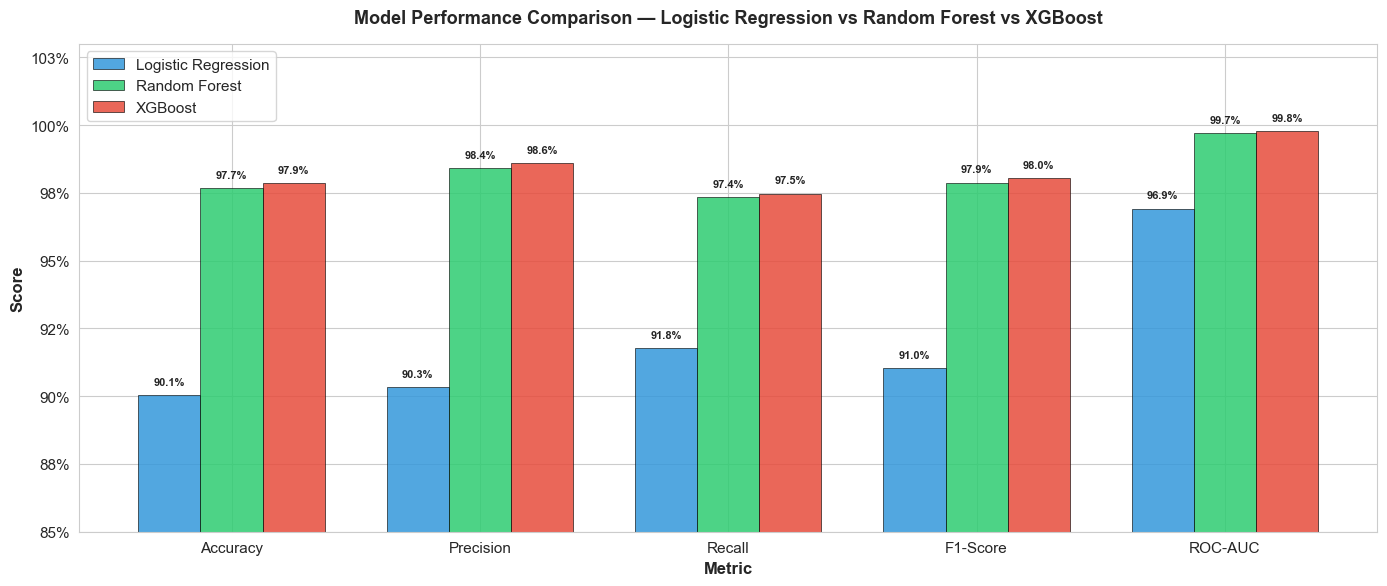

Saved: fig3_model_comparison.png


In [23]:
metrics    = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
models     = list(results.keys())
colors     = ['#3498db', '#2ecc71', '#e74c3c']
x          = np.arange(len(metrics))
width      = 0.25

fig, ax = plt.subplots(figsize=(14, 6))

for i, (model, color) in enumerate(zip(models, colors)):
    vals = [float(results[model][m]) for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=model,
                  color=color, alpha=0.85, edgecolor='black', linewidth=0.5)
    # Add value labels on bars
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val*100:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Metric', fontweight='bold', fontsize=12)
ax.set_ylabel('Score', fontweight='bold', fontsize=12)
ax.set_title('Model Performance Comparison — Logistic Regression vs Random Forest vs XGBoost',
             fontweight='bold', fontsize=13, pad=15)
ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0.85, 1.03)
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
plt.tight_layout()
plt.savefig('fig3_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig3_model_comparison.png")


---
### 6. Confusion Matrices

A confusion matrix shows:
- **True Negatives (TN)** — Normal traffic correctly identified
- **False Positives (FP)** — Normal traffic wrongly flagged as attack *(false alarms)*
- **False Negatives (FN)** — Actual attacks missed *(most dangerous!)*
- **True Positives (TP)** — Attacks correctly detected


Logistic Regression:
  Attacks correctly detected : 8,320 / 9,067 (91.8%)
  Attacks missed (FN)         : 747 (8.2%)
  False alarms (FP)           : 891

Random Forest:
  Attacks correctly detected : 8,827 / 9,067 (97.4%)
  Attacks missed (FN)         : 240 (2.6%)
  False alarms (FP)           : 142

XGBoost:
  Attacks correctly detected : 8,838 / 9,067 (97.5%)
  Attacks missed (FN)         : 229 (2.5%)
  False alarms (FP)           : 125



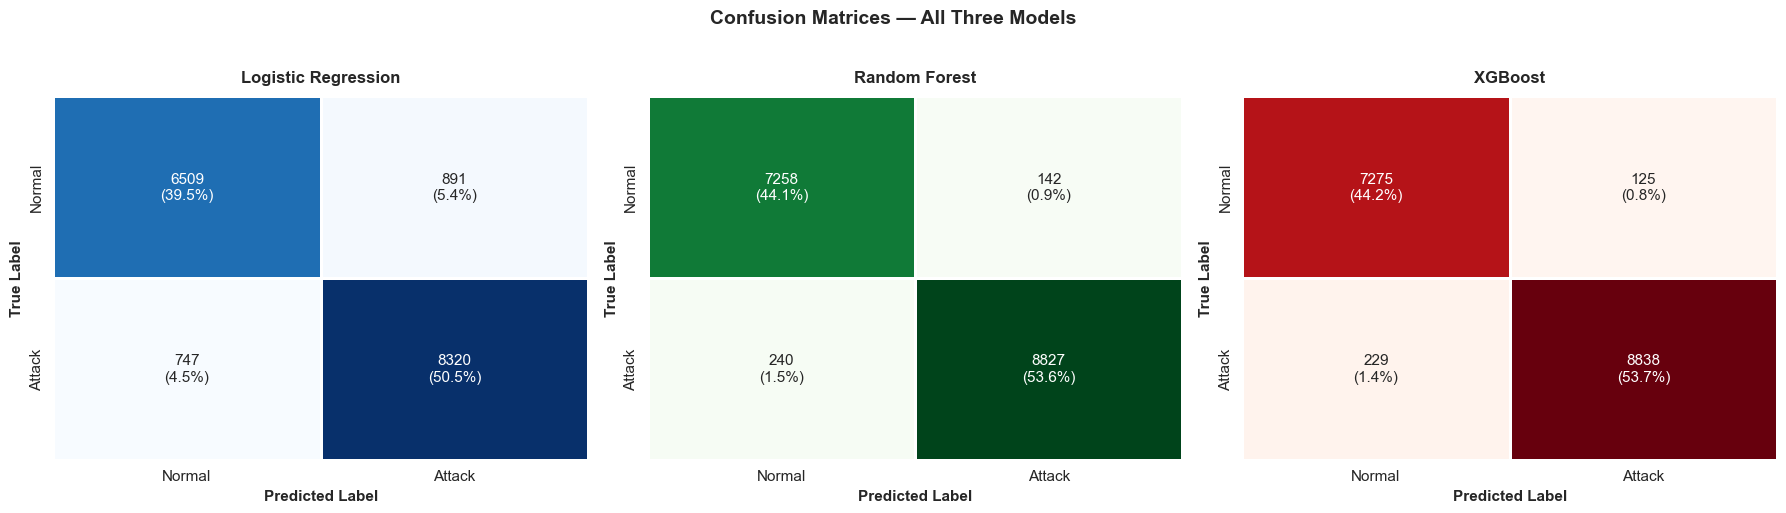

Saved: fig4_confusion_matrices.png


✅ Saved: fig4_confusion_matrices.png


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_colors = ['Blues', 'Greens', 'Reds']

for ax, (model_name, color) in zip(axes, zip(models, model_colors)):
    cm = confusion_matrix(y_test, predictions[model_name])
    
    # Annotate with counts AND percentages
    total = cm.sum()
    annot = np.array([[f'{v}\n({v/total*100:.1f}%)' for v in row] for row in cm])
    
    sns.heatmap(cm, annot=annot, fmt='', cmap=color, ax=ax,
                linewidths=1, linecolor='white', cbar=False,
                xticklabels=['Normal', 'Attack'],
                yticklabels=['Normal', 'Attack'],
                annot_kws={'size': 11})
    
    ax.set_title(f'{model_name}', fontweight='bold', fontsize=12, pad=10)
    ax.set_xlabel('Predicted Label', fontweight='bold')
    ax.set_ylabel('True Label', fontweight='bold')
    
    # Print key stats below
    tn, fp, fn, tp = cm.ravel()
    acc = (tp + tn) / total * 100
    miss_rate = fn / (fn + tp) * 100
    print(f"{model_name}:")
    print(f"  Attacks correctly detected : {tp:,} / {tp+fn:,} ({100-miss_rate:.1f}%)")
    print(f"  Attacks missed (FN)         : {fn:,} ({miss_rate:.1f}%)")
    print(f"  False alarms (FP)           : {fp:,}")
    print()

plt.suptitle('Confusion Matrices — All Three Models', 
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig4_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig4_confusion_matrices.png")


---
###  7. ROC Curves

The ROC curve shows how well a model separates attacks from normal traffic.  
**AUC (Area Under Curve) closer to 1.0 = better model.**  
The diagonal line = a random guess (AUC = 0.5).


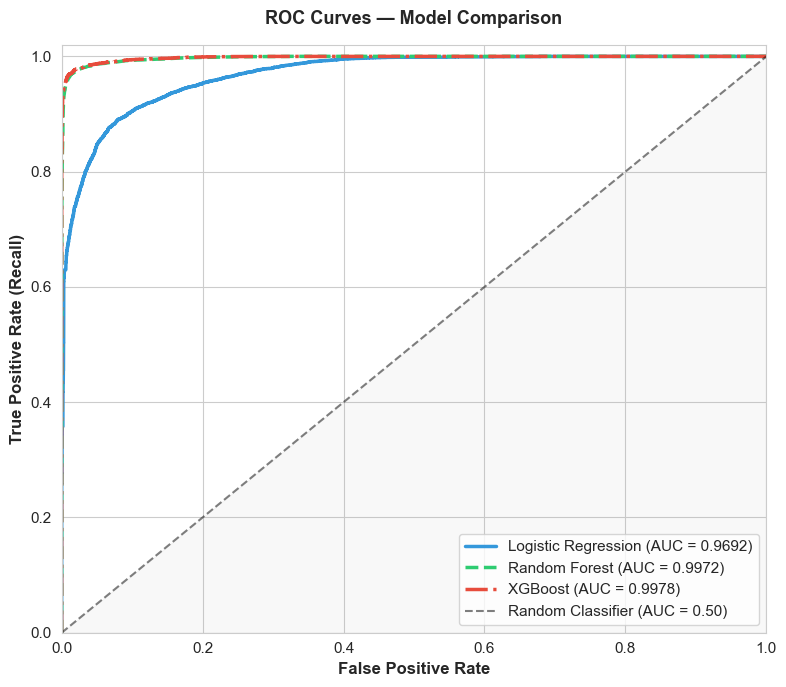

Saved: fig5_roc_curves.png


In [27]:
fig, ax = plt.subplots(figsize=(8, 7))
line_colors = ['#3498db', '#2ecc71', '#e74c3c']
line_styles = ['-', '--', '-.']

for model_name, color, ls in zip(models, line_colors, line_styles):
    fpr, tpr, _ = roc_curve(y_test, probabilities[model_name])
    auc_score   = float(results[model_name]['ROC-AUC'])
    ax.plot(fpr, tpr, color=color, lw=2.5, linestyle=ls,
            label=f'{model_name} (AUC = {auc_score:.4f})')

# Random baseline
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Random Classifier (AUC = 0.50)')

ax.fill_between([0,1], [0,1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate', fontweight='bold', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontweight='bold', fontsize=12)
ax.set_title('ROC Curves — Model Comparison', fontweight='bold', fontsize=13, pad=15)
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('fig5_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig5_roc_curves.png")


---
###  8. Detailed Classification Reports

In [29]:
for model_name in models:
    print("=" * 55)
    print(f"  {model_name}")
    print("=" * 55)
    print(classification_report(y_test, predictions[model_name],
                                 target_names=['Normal Traffic', 'Cyber Attack']))
    print()


  Logistic Regression
                precision    recall  f1-score   support

Normal Traffic       0.90      0.88      0.89      7400
  Cyber Attack       0.90      0.92      0.91      9067

      accuracy                           0.90     16467
     macro avg       0.90      0.90      0.90     16467
  weighted avg       0.90      0.90      0.90     16467


  Random Forest
                precision    recall  f1-score   support

Normal Traffic       0.97      0.98      0.97      7400
  Cyber Attack       0.98      0.97      0.98      9067

      accuracy                           0.98     16467
     macro avg       0.98      0.98      0.98     16467
  weighted avg       0.98      0.98      0.98     16467


  XGBoost
                precision    recall  f1-score   support

Normal Traffic       0.97      0.98      0.98      7400
  Cyber Attack       0.99      0.97      0.98      9067

      accuracy                           0.98     16467
     macro avg       0.98      0.98      0.98 

---
###  9. Save Best Model for XAI Step

In [31]:
import pickle

best_model_name = max(results, key=lambda m: float(results[m]['F1-Score']))
best_model_obj  = trained_models[best_model_name]

# Save best model
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model_obj, f)

# Save all models
with open('all_models.pkl', 'wb') as f:
    pickle.dump(trained_models, f)

# Save results table
pd.DataFrame(results).T.to_csv('model_results.csv')

print(f" Best model saved : best_model.pkl  ({best_model_name})")
print(f" All models saved : all_models.pkl")
print(f" Results table    : model_results.csv")
print(f"\n   Best model F1  = {float(results[best_model_name]['F1-Score'])*100:.2f}%")
print(f"   Best model AUC = {float(results[best_model_name]['ROC-AUC'])*100:.2f}%")


 Best model saved : best_model.pkl  (XGBoost)
 All models saved : all_models.pkl
 Results table    : model_results.csv

   Best model F1  = 98.04%
   Best model AUC = 99.78%


---
###  Step 2 Complete — Results Summary

| Model | Accuracy | Precision | Recall | F1-Score | ROC-AUC | Train Time |
|---|---|---|---|---|---|---|
| Logistic Regression | 90.05% | 90.32% | 91.76% | 91.03% | 96.92% | 1.14s |
| Random Forest | 97.71% | 98.37% | 97.45% | 97.91% | 99.73% | 9.97s |
| **XGBoost** | **97.85%** | **98.61%** | **97.47%** | **98.04%** | **99.78%** | **1.32s** |

---

**Key Findings:**
-  **XGBoost is the best model** — highest F1 (98.04%) and AUC (99.78%) with very fast training (1.32s)
- Random Forest is very close but takes 7x longer to train
- Logistic Regression is the weakest — confirms that cyber attack patterns are **non-linear** (complex relationships)
- All models have very low False Negative rates — meaning very few real attacks are being missed

**Supply Chain Governance Implication:**  
XGBoost's near-perfect AUC of 99.78% means the system can distinguish attacks from normal traffic with extreme reliability — a critical requirement before we can trust it to trigger automatic governance responses.


